In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "week6" else _cwd
sys.path.insert(0, os.path.join(_root, "week5"))
sys.path.insert(0, os.path.join(_root, "week6"))

from data import Electricity
from decomposition import decompose_series, decomposition_summary, select_representative_users

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams["axes.unicode_minus"] = False

## 1. 数据加载

这里直接复用 `week5/data.py` 中的 `Electricity` 类。第六周只做分解分析，因此我们读取原始多用户负荷序列，不构造滑窗。

In [2]:
# Electricity 类内部已经处理了数据路径。
elec = Electricity(test_ratio=0.2)

# 原始表：date 列 + 多个用户列 + OT 列。
raw_df = elec.df.copy()
raw_df["date"] = pd.to_datetime(raw_df["date"])
user_cols = elec.user_cols

print(f"数据形状: {raw_df.shape}")
print(f"用户数量: {len(user_cols)}")
print(f"时间范围: {raw_df['date'].min()} -> {raw_df['date'].max()}")

数据形状: (26304, 322)
用户数量: 320
时间范围: 2016-07-01 02:00:00 -> 2019-07-02 01:00:00


## 2. 设置分解参数并选择展示用户


- `period = 24`：小时级用电数据按日周期分解。
- `trend_window = 25`：用居中的 25 点移动平均提取趋势。

为了让波形更容易观察，下面自动挑选波动较明显的 3 个用户。

In [3]:
PERIOD = 24
TREND_WINDOW = 25
VIEW_DAYS = 14
VIEW_STEPS = PERIOD * VIEW_DAYS

# 选择标准差较大的 3 个用户，展示其日内周期与趋势变化会更清楚。
selected_users = select_representative_users(raw_df, user_cols, n_users=3)
print("用于考核展示的 3 个用户:", selected_users)

用于考核展示的 3 个用户: ['313', '155', '236']


## 3. 对 3 个用户做序列分解

分解结果包含 2 个部分：

- `observed`：原始负荷序列
- `trend`：移动平均得到的趋势项
- `periodic`：按 24 小时模板重建的周期项,包含常规分解中的residual
- `observed` = `trend` + `periodic`


In [4]:
decomposition_results = {}

for user_id in selected_users:
    series = raw_df[user_id].astype(float).to_numpy()
    decomposition_results[user_id] = decompose_series(
        series=series,
        period=PERIOD,
        trend_window=TREND_WINDOW,
    )

print("已完成分解的用户:", list(decomposition_results.keys()))

已完成分解的用户: ['313', '155', '236']


## 4. 考核检查点：展示 3 个用户的原始负荷、趋势项、周期项

为便于观察，默认展示前 14 天。可以调大 `VIEW_DAYS` 查看更长时间范围。

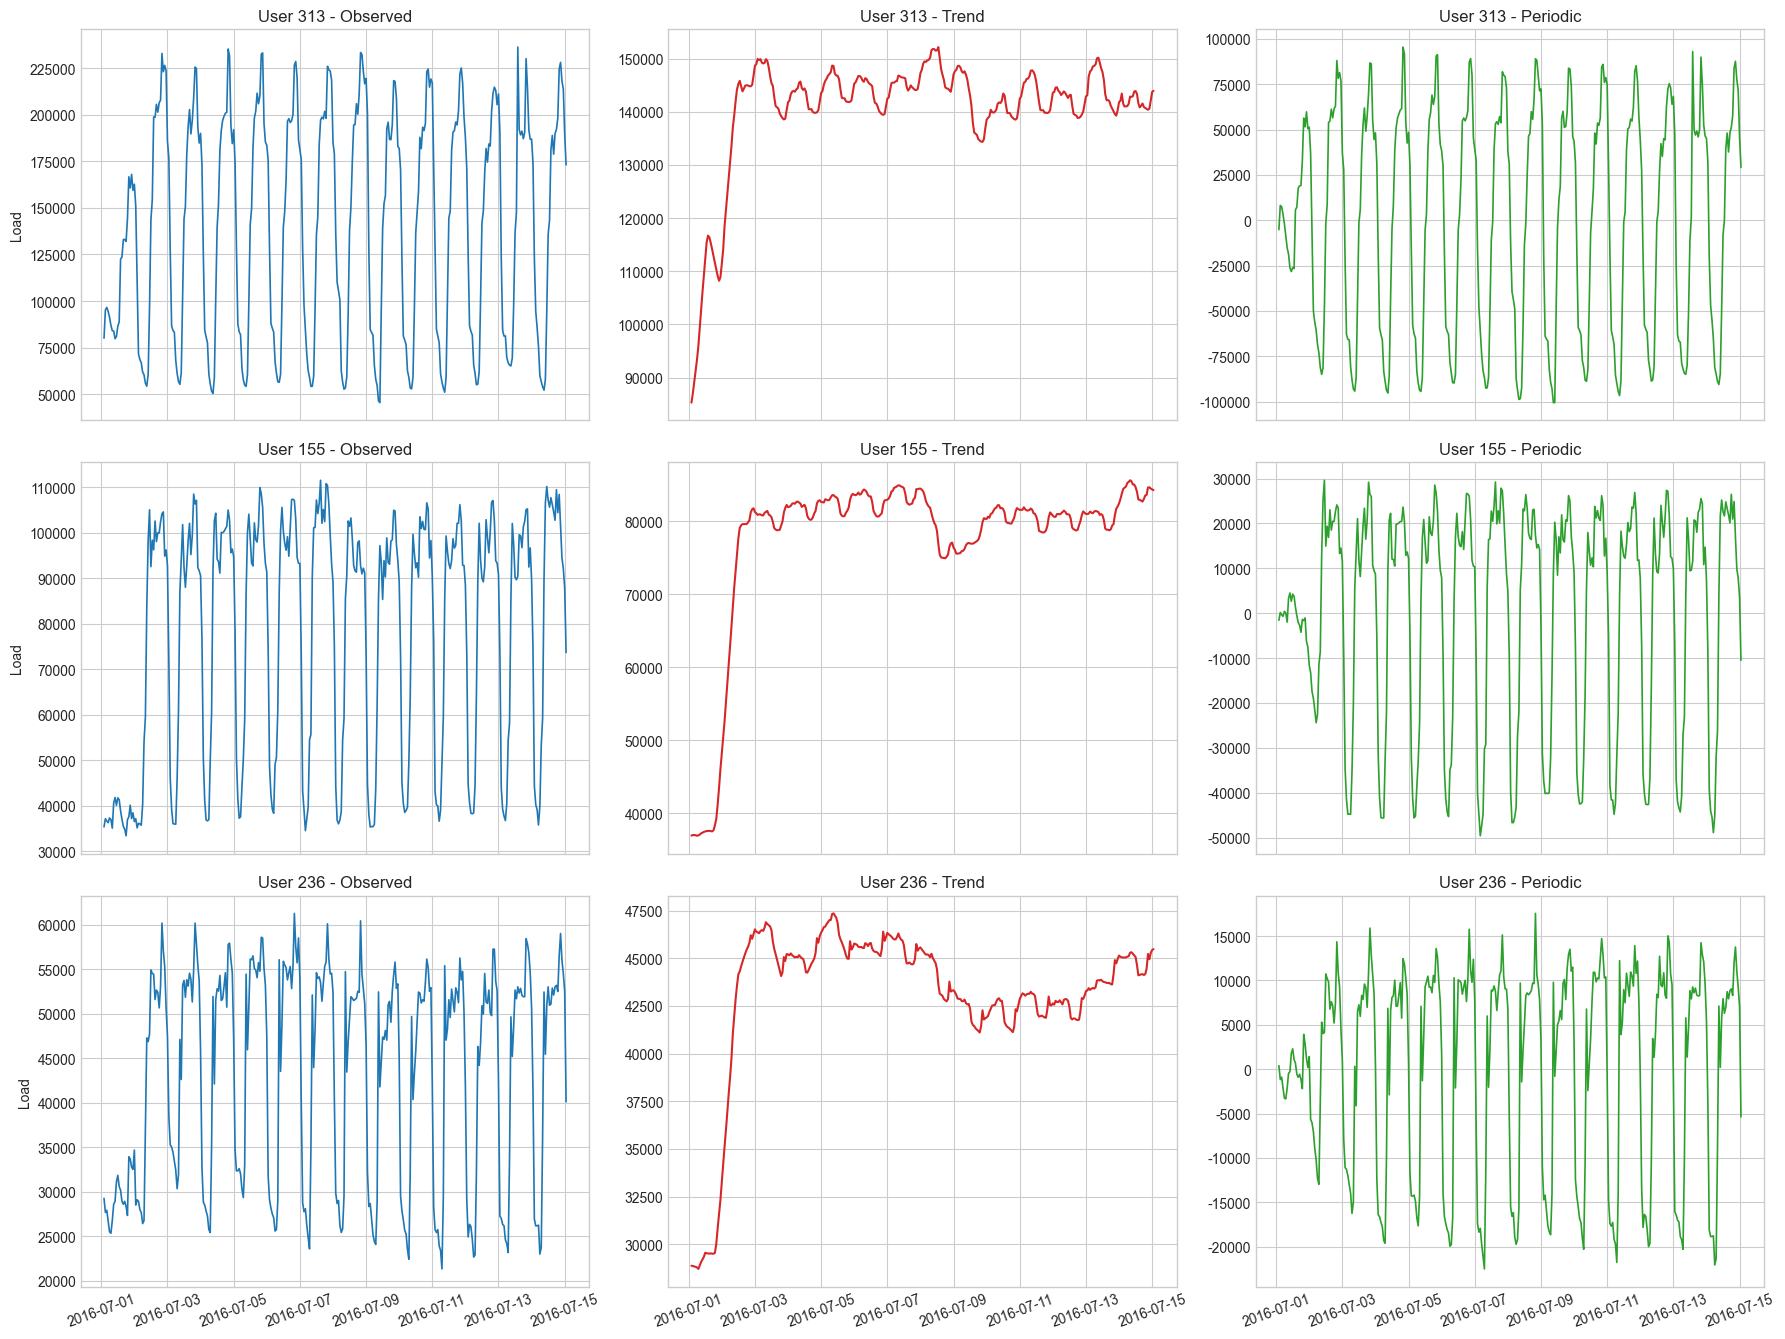

In [5]:
time_axis = raw_df["date"].iloc[:VIEW_STEPS]

fig, axes = plt.subplots(len(selected_users), 3, figsize=(18, 4.5 * len(selected_users)), sharex=True)
if len(selected_users) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, user_id in enumerate(selected_users):
    comp = decomposition_results[user_id]

    # 第 1 列：原始负荷。
    axes[row_idx, 0].plot(time_axis, comp["observed"][:VIEW_STEPS], color="#1f77b4", linewidth=1.2)
    axes[row_idx, 0].set_title(f"User {user_id} - Observed")
    axes[row_idx, 0].set_ylabel("Load")

    # 第 2 列：趋势项。
    axes[row_idx, 1].plot(time_axis, comp["trend"][:VIEW_STEPS], color="#d62728", linewidth=1.5)
    axes[row_idx, 1].set_title(f"User {user_id} - Trend")

    # 第 3 列：周期项。
    axes[row_idx, 2].plot(time_axis, comp["periodic"][:VIEW_STEPS], color="#2ca02c", linewidth=1.2)
    axes[row_idx, 2].set_title(f"User {user_id} - Periodic")

for ax in axes[-1, :]:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 5. 分解结果摘要

- `trend_var` 越大，说明长期变化更明显。
- `periodic_var` 越大，说明日内重复模式更明显。
- `reconstruction_mae` 应接近 0，因为原序列可以由 `trend + periodic` 重构。

In [6]:
summary_rows = []

for user_id in selected_users:
    metrics = decomposition_summary(decomposition_results[user_id])
    metrics["user_id"] = user_id
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows)[[
    "user_id",
    "observed_var",
    "trend_var",
    "periodic_var",
    "reconstruction_mae"
]]

summary_df = summary_df.sort_values(by="observed_var", ascending=False).reset_index(drop=True)
summary_df

,user_id,observed_var,trend_var,periodic_var,reconstruction_mae
0,313,2.133114e+10,5.781081e+09,1.667546e+10,0.0
1,155,6.728238e+08,1.197208e+08,5.882944e+08,0.0
2,236,1.323594e+08,1.756186e+07,1.200524e+08,0.0
